In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
from sdv.metadata import SingleTableMetadata
# from sdv.single_table import CopulaGANSynthesizer, TVAESynthesizer, CTGANSynthesizer
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import shap


import optuna

device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('train_data.csv')
data = data.drop(['Этаж', 'Район', 'id', 'date', 'rooms', 'Цена', 'nprice'], axis=1)
data['day'] = pd.to_datetime(data['day'])
data['date'] = data['day']
data['month'] = data['day'].dt.month
data['year'] = data['day'].dt.year
data['day'] = data['day'].dt.day
data = data.dropna()

data = data.sort_values(by='date').reset_index(drop=True)
data = data.drop('date', axis=1)

data = pd.concat([data.drop('pricemetr', axis=1), data['pricemetr']], axis=1)

feat_name = 'floor'
# data = pd.concat([data[feat_name], data.drop(feat_name, axis=1)], axis=1)



cat_cols_name = np.array(['day', 'Квартиры среднего качества (типовые)', 'month'])
cat_cols_name_w_feat = np.hstack([cat_cols_name])

num_cols_name = np.setdiff1d(data.columns, cat_cols_name)
num_cols_name = np.setdiff1d(num_cols_name, [feat_name, 'pricemetr'])
num_cols_name_w_feat = np.hstack([[feat_name], num_cols_name, ['pricemetr']])

data = pd.concat([data[np.hstack(['floor', cat_cols_name])], data[np.hstack([num_cols_name, 'pricemetr'])]], axis=1)

In [3]:
length_num = len(num_cols_name)
length_cat = len(cat_cols_name)

In [6]:
# data.drop(['floor', 'pricemetr'], axis=1).iloc[:, length_cat:]

In [7]:
# X, y = data.drop('pricemetr', axis=1), data['pricemetr']

In [8]:
scaler_num = MinMaxScaler()
# scaler_cat = MinMaxScaler()
label_encoder = LabelEncoder()

data_unnormalized = copy.deepcopy(data)
data_unnormalized[num_cols_name_w_feat] = scaler_num.fit_transform(data_unnormalized[num_cols_name_w_feat])

# label_encoders_arr = []
# for col in cat_cols_name:
#     label_encoder = LabelEncoder()
#     data_unnormalized[col] = label_encoder.fit_transform(data_unnormalized[col])
#     label_encoders_arr.append(label_encoder)
    

data[num_cols_name_w_feat] = scaler_num.transform(data[num_cols_name_w_feat])
# data[cat_cols_name_w_feat] = scaler_cat.fit_transform(data[cat_cols_name_w_feat])

In [9]:
data_vae = copy.deepcopy(data_unnormalized)

In [10]:
data_vae = pd.concat([data_vae[feat_name], pd.get_dummies(data_vae[cat_cols_name].astype(str)).astype(float), data_vae[num_cols_name], data_vae['pricemetr']], axis=1)

## Baseline regression

In [ ]:
# scaler = MinMaxScaler()
# data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

X_train, X_test, y_train, y_test = train_test_split(data_vae.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.3, random_state=55555)

xgb = XGBRegressor()

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [952]:
mean_absolute_percentage_error(y_test.values, xgb_pred), r2_score(y_test.values, xgb_pred)

(0.09472986192958076, 0.852749380900035)

In [953]:
# z = 0.5
# f = lambda arr: np.array(list(map(lambda y: 2 * y + 0.1, arr)))

# idx = X_test[X_test['floor'] > z].index

# plt.scatter(X_test['floor'].loc[idx], y_test.loc[idx])
# plt.scatter(X_test['floor'].loc[idx], f(y_test.loc[idx]))

# plt.show()

In [954]:
# sc_target = f(y_test.loc[idx])

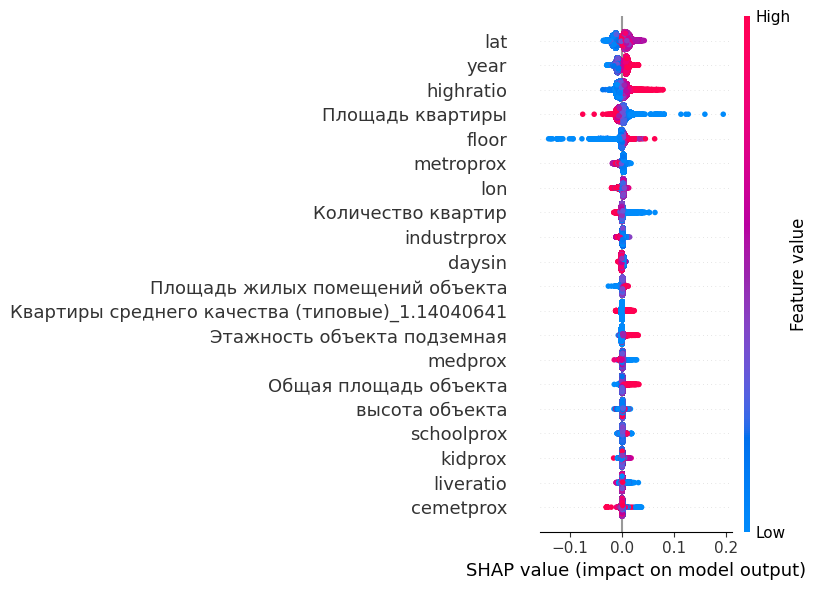

In [955]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(X_test)
shap.summary_plot(explanation, plot_size=[8,6])

## Distillation

In [956]:
class RegressionDistill(nn.Module):
    def __init__(self, in_dim):
        super(RegressionDistill, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(in_dim, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 1),
        )
        
    def forward(self, x):
        out = self.model(x)
        
        return out
    
    
class DataseCustom(torch.utils.data.Dataset):
    def __init__(self, data, data_distill):
        self.data = data
        self.data_distill = data_distill

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return [self.data[idx], self.data_distill[idx]]

In [957]:
data_reg = np.array(data_vae).astype('float32')
data_reg = torch.tensor(data_reg).to(device)

y_for_distill = torch.tensor(xgb.predict(data_vae.drop('pricemetr', axis=1)).reshape(-1, 1)).to(device)

reg_dataset = DataseCustom(data_reg, y_for_distill)
reg_loader = torch.utils.data.DataLoader(reg_dataset, batch_size=256, shuffle=True)

In [958]:
reg_model = RegressionDistill(X_train.shape[1]).to(device)
optim_reg = optim.AdamW(reg_model.parameters(), lr=3e-4)

epochs = tqdm(range(50))

for _ in epochs:
    for data_x, data_d in reg_loader:
        
        reg_pred = reg_model(data_x[:, :-1])
        
        loss = 0.1 * torch.mean( (reg_pred - data_x[:, -1])**2 ) + torch.mean( (reg_pred - data_d)**2 )
        
        optim_reg.zero_grad()
        loss.backward()
        # torch.nn.utils.clip_grad_norm_(reg_model.parameters(), max_norm=1)
        optim_reg.step()
        
    epochs.set_description(f'{loss.item()}')

  0%|          | 0/50 [00:00<?, ?it/s]

0.00022511908900924027: 100%|██████████| 50/50 [01:58<00:00,  2.37s/it]


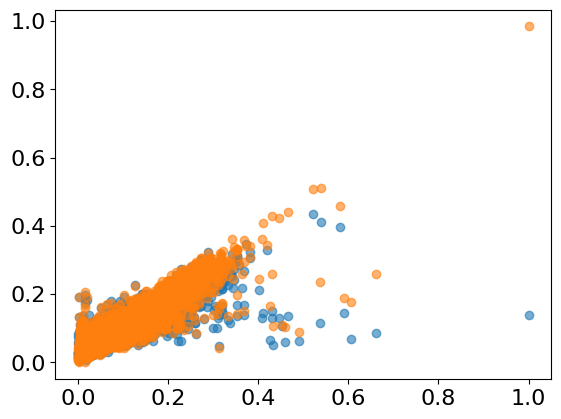

In [959]:
plt.scatter(y_train.values, reg_model(torch.tensor(X_train.values.astype('float32')).to(device)).detach().cpu().numpy().T[0], alpha=0.6)
plt.scatter(y_train.values, xgb.predict(X_train), alpha=0.6)

plt.show()

In [963]:
reg_model.eval()

for param in reg_model.parameters():
    param.requires_grad = False

In [964]:
mean_absolute_percentage_error(y_test.values, xgb.predict(X_test)), r2_score(y_test.values, xgb.predict(X_test))

(0.09472986192958076, 0.852749380900035)

## Generator

In [1112]:
class DataseCustomScenario(torch.utils.data.Dataset):
    def __init__(self, data_wo_x, X_for_sc, y_sc):
        self.data_wo_x = data_wo_x
        self.y_sc = y_sc
        self.X_for_sc = X_for_sc

    def __len__(self):
        return len(self.data_wo_x)

    def __getitem__(self, idx):
        return [self.data_wo_x[idx], self.X_for_sc[idx], self.y_sc[idx]]
    
z = 0.7
idx_sc = data_vae[data_vae['floor'] > z].index
f = lambda arr: np.array(list(map(lambda y: 0.0 * y + 0.1, arr))) #+  0.1 * np.sin(np.linspace(0, 1, len(arr))*5)

# def f(data):
#     sc = lambda arr: np.array(list(map(lambda y: 0.5 * y, arr))) + 0.1 * np.sin(np.linspace(0, 1, len(arr))*5)
    
#     idx_after_sort = data.loc[idx_sc, 'pricemetr'].sort_values().index
#     y_sc = data.loc[idx_sc, 'pricemetr'].sort_values().values.astype('float32')
#     y_sc = pd.DataFrame(sc(y_sc))
    
#     y_sc.index = idx_after_sort
#     y_sc = y_sc.loc[idx_sc].values.astype('float32')

#     return y_sc

data_wo_x = torch.tensor(data_vae.loc[idx_sc].drop([feat_name, 'pricemetr'], axis=1).values.astype('float32'))

# y_sc = torch.tensor( f(data.loc[idx_sc, 'pricemetr'].values.astype('float32')) ).view(-1, 1)
# y_sc = f(data)
y_sc = np.array(sorted(np.array(list(zip(np.arange(len(idx_sc)), \
                                    data_vae[feat_name].loc[idx_sc].values, \
                                    f(data_vae.loc[idx_sc,'pricemetr']))
                                     )),\
                key=lambda x: x[1]))
y_sc[:, 2] = y_sc[:, 2] - 0.1 *  np.linspace(0, 1, len(y_sc))
y_sc = np.array(sorted(y_sc, key=lambda x: x[0]))
y_sc = torch.tensor(y_sc[:, 2].astype('float32')).view(-1, 1)


X_for_sc = torch.tensor(data_vae.loc[idx_sc, feat_name].values.astype('float32')).view(-1, 1)


sc_dataset = DataseCustomScenario(data_wo_x.unsqueeze(1), X_for_sc, y_sc)
sc_loader = torch.utils.data.DataLoader(sc_dataset, batch_size=256, shuffle=True)

In [1113]:
# sc = lambda arr: np.array(list(map(lambda y: 0.5 * y + 0.2, arr))) + 0.1 * np.sin(10 * np.linspace(0, 1, len(arr)))

# idx_after_sort = data.loc[idx_sc, 'pricemetr'].sort_values().index
# y_sc = data.loc[idx_sc, 'pricemetr'].sort_values().values.astype('float32')
# y_sc = pd.DataFrame(sc(y_sc))

# y_sc.index = idx_after_sort
# y_sc = y_sc.loc[idx_sc].values.astype('float32')

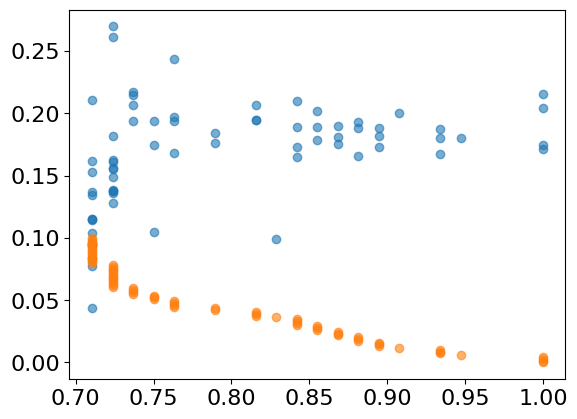

In [1114]:
plt.scatter(data_vae['floor'].loc[idx_sc], data_vae.loc[idx_sc, 'pricemetr'], alpha=0.6)
# plt.scatter(data['floor'].loc[idx_sc], f(data.loc[idx_sc,'pricemetr']), alpha=0.6)
plt.scatter(data_vae['floor'].loc[idx_sc], y_sc, alpha=0.6)
# plt.scatter(data['floor'].loc[idx_sc], xgb.predict(synth_df), alpha=0.6)

plt.show()

In [1115]:
# pos = np.where(data.columns == 'floor')[0][0]
# pos

In [1116]:
num_classes_all = []

for i in cat_cols_name:
    num_classes_all.append(len(data_unnormalized.loc[:, i].unique()))

In [985]:
sum_classes_all = sum(num_classes_all)

In [1119]:
sum_classes_all + length_num

92

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.2)
        self.drop2 = nn.Dropout(0.2)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32):
        super(VAE, self).__init__()
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        # self.h_dim_enc = seq_length * hidden_channels
        self.h_dim_enc = seq_length * hidden_channels
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_enc))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.SiLU()
        
        
        self.num_classes_for_all = num_classes_all
        self.fc_logits = nn.Linear(sum_classes_all, sum_classes_all)

    def encode(self, x):
        x = self.enc_conv1(x)
        
        x = self.act(x)
        x = self.enc_res1(x)
        
        x = self.enc_conv2(x)
        x = self.act(x)

        x = self.enc_res2(x)
        x = x.view(x.size(0), -1)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar
    

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std


    def decode(self, z):
        # conv_out_length = (self.seq_length) // 4
        x = self.fc_decode(z)
        
        x = x.view(z.size(0), self.hidden_channels, self.seq_length)
        
        x = self.dec_conv1(x)
        x = self.act(x)
        
        x = self.dec_res1(x)
        
        x = self.dec_conv2(x)
        x = self.dec_res2(x)
        
        x = self.dec_conv3(x)    # (BS, 1, 221)
        
        x_cat = x[:, :, :sum_classes_all]
        x_num = x[:, :, sum_classes_all:]
        
        # x_cat_logits = torch.split(self.fc_logits(x_cat), self.num_classes_for_all, dim=2)
        
        return F.sigmoid(x_num), x_cat



    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x_num, recon_x_logits = self.decode(z)
        
        return recon_x_num, recon_x_logits, mu, logvar
    
    

def vae_loss(recon_x_num, recon_x_logits, x, X_for_sc, y_sc, mu, logvar, beta, reg_model):
    mse_loss = F.mse_loss(recon_x_num, x[:, :, sum_classes_all:], reduction='mean')
    
    # ce_loss = 0
    # for i, logits in enumerate(recon_x_logits):
        # ce_loss += F.cross_entropy(logits.squeeze(), x[:, :, :sum_classes_all].squeeze(1)[:, i].long(), reduction='mean')
    # print(F.gumbel_softmax(recon_x_logits.squeeze(), tau=0.5, hard=False, dim=1), x[:, :, :sum_classes_all].size())
    ce_loss = F.cross_entropy(recon_x_logits.squeeze(), x[:, :, :sum_classes_all].squeeze(1), reduction='mean')

    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
   
    # left = recon_x.squeeze(1)[:, :pos]
    # right = recon_x.squeeze(1)
    
    generated_labels = []
    # generated_labels = torch.zeros((x.size(0), length_cat)).requires_grad_(True)
    
    for logits in recon_x_logits:
        # probs = F.softmax(logits.squeeze(), dim=1)

        # sample = torch.multinomial(probs, 1).squeeze()
    
        sample = F.gumbel_softmax(logits.squeeze(), tau=0.5, hard=False, dim=0)
        
  
        generated_labels.append(sample)
        
    
    generated_labels = torch.stack(generated_labels, dim=1)
    
    reg_tensor = torch.cat((X_for_sc, generated_labels, recon_x_num.squeeze(1)), dim=1)
    reg_pred_synth = reg_model(reg_tensor)
    ml_loss = torch.mean( (reg_pred_synth - y_sc)**2 )
    
    return (mse_loss + ce_loss) + beta * kl_loss + ml_loss


def train_vae(model, train_loader, reg_model, num_epochs=500, learning_rate=1e-3, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.0005, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model.train()
    for epoch in epochs:
        epoch_loss = 0
        
        for data, X_for_sc, y_sc in train_loader:
            data = data.to(device)
            
            # one_hot_list = []
            # for i in range(length_cat):
            #     one_hot = F.one_hot(data[:, :, :length_cat].squeeze(1)[:, i].long(), num_classes=num_classes_all[i]).float()
            #     one_hot_list.append(one_hot)
                
            # data_cat = torch.cat(one_hot_list, dim=1).to(device).unsqueeze(1)
            # data_num = data[:, :, length_cat:]
            # u = torch.cat([data_num, data_cat], dim=2)
            
            recon_x_num, recon_x_logits, mu, logvar = model(data)
            
            loss = vae_loss(recon_x_num, recon_x_logits, data, X_for_sc, y_sc, mu, logvar, beta_sch[epoch], reg_model)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        # print(optimizer.param_groups[0]['lr'])
        if epoch % 100 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}')
            
    return losses 

In [1118]:
seq_length = sum_classes_all + length_num

# Initialize the VAE model
model_vae = VAE(input_channels=1, seq_length=seq_length, latent_dim=128, hidden_channels=16)

# Train the VAE
losses_vae = train_vae(model_vae, sc_loader, reg_model, num_epochs=3_000, learning_rate=2e-3)

Average Loss: 0.0476: 100%|██████████| 3000/3000 [02:02<00:00, 24.47it/s]


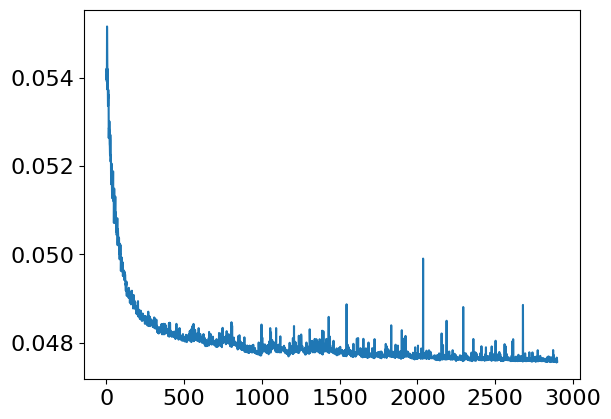

In [1120]:
plt.plot(losses_vae[100:])
plt.show()

In [1121]:
model_vae.eval()

# one_hot_list = []
# for i in range(length_cat):
#     one_hot = F.one_hot(data_wo_x[:, :length_cat].squeeze(1)[:, i].long(), num_classes=num_classes_all[i]).float()
#     one_hot_list.append(one_hot)
    
# data_cat = torch.cat(one_hot_list, dim=1).to(device).unsqueeze(1)
# data_num = data_wo_x[:, length_cat:].unsqueeze(1)
# x = torch.cat([data_num, data_cat], dim=2)

synth_num, synth_cat, mu, logvar = model_vae(data_wo_x.unsqueeze(1))
# synth_vae = synth_vae.squeeze(1).detach().cpu()
# left = synth_vae.squeeze(1)[:, :pos]
# right = synth_vae.squeeze(1)[:, pos:]
# synth_vae = torch.cat((left, X_for_sc, right), dim=1)
# synth_df = pd.DataFrame(synth_vae.numpy(), columns=data.columns[:-1])

In [1122]:
generated_labels = []

for logits in synth_cat:
    sample = F.gumbel_softmax(logits.squeeze(), tau=0.5, hard=True, dim=0)
    generated_labels.append(sample)
    
generated_labels = torch.stack(generated_labels, dim=1)

In [1123]:
generated_labels.size()

torch.Size([70, 70])

In [1124]:
# generated_labels = []
# for logits in synth_cat:
#     probs = F.softmax(logits.squeeze(), dim=1)
#     sample = torch.multinomial(probs, 1).squeeze()
#     generated_labels.append(sample)
    
# generated_labels = torch.stack(generated_labels, dim=1)

In [1125]:
synth_vae = torch.cat([X_for_sc, generated_labels, synth_num.squeeze(1)], dim=1).detach().cpu().numpy()
synth_df = pd.DataFrame(synth_vae, columns=data_vae.columns[:-1])

In [1126]:
# synth_pred = xgb.predict(synth_df)

# plt.scatter(y_test.loc[idx_sc].values, xgb.predict(data.loc[idx_sc]), alpha=0.8, label='Real bad X')
# plt.scatter(y_test.loc[idx_sc].values, synth_pred, alpha=0.8, label='Synth bad X')

# plt.legend()
# plt.show()

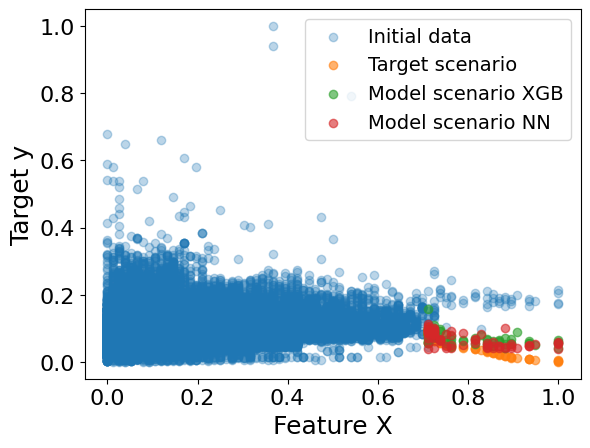

In [1127]:
# plt.scatter(X_test['floor'].loc[idx], y_test.loc[idx])
# plt.scatter(X_test['floor'].loc[idx], f(y_test.loc[idx]))
# plt.scatter(X_test['floor'].loc[idx], xgb.predict(synth_df))

# plt.show()


plt.scatter(data_vae['floor'], data_vae['pricemetr'], alpha=0.3, label='Initial data')
plt.scatter(data_vae['floor'].loc[idx_sc], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(data_vae['floor'].loc[idx_sc], xgb.predict(synth_df), alpha=0.6, label='Model scenario XGB')
plt.scatter(data_vae['floor'].loc[idx_sc], reg_model(torch.tensor(synth_df.values)).numpy().flatten(), alpha=0.6, label='Model scenario NN')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [1097]:
data_vae.loc[idx_sc]

,floor,day_1,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,...,year,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,Площадь квартиры,Этажность объекта наземная,Этажность объекта подземная,высота объекта,количество этажей всего,pricemetr
7450,0.723684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.142857,0.115644,0.152399,0.226974,0.165537,0.813953,0.304348,0.861308,0.855556,0.269738
43095,0.763158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.285714,0.115644,0.152399,0.226974,0.515558,0.813953,0.304348,0.861308,0.855556,0.243378
44078,0.710526,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.285714,0.142216,0.126977,0.195316,0.115433,0.627907,0.086957,0.567572,0.622222,0.094836
44295,0.710526,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.285714,0.142216,0.126977,0.195316,0.115433,0.627907,0.086957,0.567572,0.622222,0.093866
44303,0.710526,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.285714,0.142216,0.126977,0.195316,0.112087,0.627907,0.086957,0.567572,0.622222,0.094836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237962,0.736842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.200225,0.176618,0.274242,0.425847,0.662791,0.086957,0.564209,0.655556,0.206347
238028,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.322605,0.440393,0.648836,0.301547,1.000000,0.173913,1.000000,1.000000,0.204135
247126,0.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.688249,0.535895,0.751725,0.205353,0.674419,0.086957,0.562635,0.666667,0.104616
249541,0.828947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,0.415419,0.252993,0.440545,0.274780,0.732558,0.086957,0.566399,0.722222,0.098845


In [1098]:
synth_df

,floor,day_1,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,...,schoolprox,year,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,Площадь квартиры,Этажность объекта наземная,Этажность объекта подземная,высота объекта,количество этажей всего
0,0.723684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.050435,0.087745,0.002994,0.202716,0.346517,0.000026,0.721472,0.262353,0.832831,0.699998
1,0.763158,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.092521,0.253557,0.002711,0.197273,0.368939,0.000030,0.737859,0.307046,0.998591,0.834112
2,0.710526,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.131108,0.356124,0.011483,0.162878,0.294336,0.000023,0.583566,0.086199,0.648386,0.567337
3,0.710526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.122756,0.338703,0.016585,0.184785,0.287156,0.000071,0.588376,0.126757,0.682052,0.559325
4,0.710526,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.197274,0.345888,0.053955,0.215712,0.318170,0.000005,0.580089,0.129844,0.653685,0.575337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,0.736842,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.145831,0.991242,0.064586,0.186569,0.345302,0.000006,0.621994,0.122932,0.670796,0.598302
66,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.143660,0.994216,0.160480,0.489670,0.753728,0.000015,0.977465,0.246046,0.999997,0.999994
67,0.750000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.320337,0.960064,0.499994,0.552639,0.881124,0.000165,0.597336,0.183057,0.656501,0.575936
68,0.828947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.230510,0.991570,0.233944,0.281486,0.499191,0.000009,0.631529,0.116638,0.670164,0.613227


In [1073]:
# for i in range(0,94, 5):
#     plt.hist(data_vae.loc[idx_sc].values[:, i], bins=40, alpha=0.7)
#     plt.hist(synth_vae[:, i], bins=40, alpha=0.7)

#     plt.show()

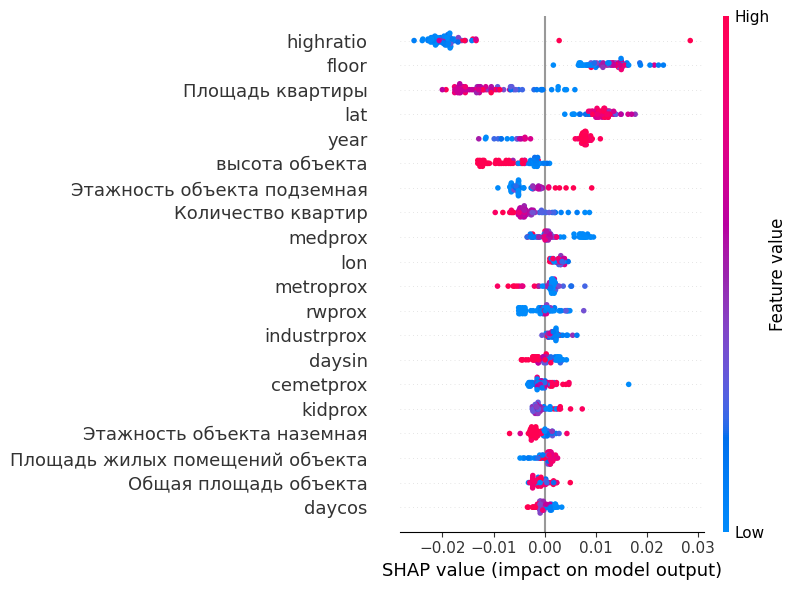

In [1128]:
explainer = shap.TreeExplainer(xgb)
# explanation = explainer(data_vae.loc[idx_sc].drop('pricemetr', axis=1))
explanation = explainer(synth_df)
shap.summary_plot(explanation, plot_size=[8,6])

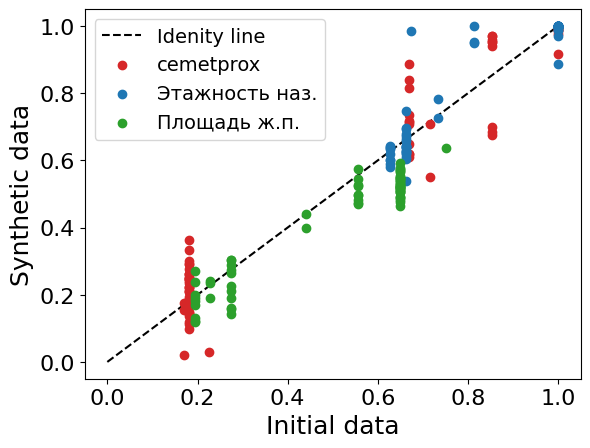

In [1156]:
plt.plot([0, 1], [0, 1], '--', color='black', label='Idenity line')
plt.scatter(data_vae.loc[idx_sc, 'cemetprox'].values, synth_df['cemetprox'].values, zorder=3, label='cemetprox', color='tab:red')
plt.scatter(data_vae.loc[idx_sc, 'Этажность объекта наземная'].values,\
            synth_df['Этажность объекта наземная'].values, zorder=3, label='Этажность наз.', color='tab:blue')
plt.scatter(data_vae.loc[idx_sc, 'Площадь жилых помещений объекта'].values,\
            synth_df['Площадь жилых помещений объекта'].values, zorder=3, label='Площадь ж.п.', color='tab:green')


plt.legend()
plt.xlabel('Initial data')
plt.ylabel('Synthetic data')
plt.show()

# Second model. Hard scenarios

### Определение значимости признаков

In [1396]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.3, random_state=55555)

In [1403]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_train, y_train)
reg_coef = lr.coef_

# mean_absolute_percentage_error(y_test.values, lr.predict(X_test)), r2_score(y_test.values, lr.predict(X_test))
# plt.bar(np.arange(len(reg_coef)), reg_coef)
# plt.show()

In [1404]:
from sklearn.feature_selection import f_regression, r_regression
from statsmodels.stats.multitest import multipletests

# X - матрица признаков (25 переменных), y - целевая переменная
f_scores, p_values = f_regression(X_train, y_train)

# Выведите результаты
# for i, (f, p) in enumerate(zip(f_scores, p_values)):
#     print(f"Признак {i+1}: F={f:.2f}, p={p:.4f}")

reject, corrected_p, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

In [1407]:
xgb = XGBRegressor()

xgb.fit(X_train, y_train)
explainer = shap.TreeExplainer(xgb)
explanation = explainer(X_train)
# shap.summary_plot(explanation, plot_size=[8,6])

In [1408]:
feat_order_df = pd.DataFrame(np.array([X_train.columns,\
                                       reg_coef,\
                                       r_regression(X_train, y_train.values.flatten()),\
                                       # reject,
                                       explanation.values.mean(0)]).T)

feat_order_df = feat_order_df.sort_values(by=[1, 2, 3], ascending=False)
feat_order_df

,0,1,2,3
24,высота объекта,0.340139,0.3984,-0.000598
19,Общая площадь объекта,0.082371,0.26079,-0.000355
17,year,0.067574,0.298744,-0.000485
0,floor,0.035629,0.260261,0.000346
2,Квартиры среднего качества (типовые),0.032541,-0.158641,0.000081
23,Этажность объекта подземная,0.023287,0.185099,-0.00003
10,lat,0.014016,0.261234,0.000005
16,schoolprox,0.009784,0.014598,0.000101
12,lon,0.008783,0.231256,0.000269
9,kidprox,0.00463,0.060125,-0.000151


In [1161]:
feat_order_names = feat_order_df[0].values
feat_order_names

array(['высота объекта', 'Общая площадь объекта', 'floor',
       'Этажность объекта подземная',
       'Квартиры среднего качества (типовые)_1.14040641',
       'Квартиры среднего качества (типовые)_1.0891',
       'Квартиры среднего качества (типовые)_1.1329', 'lat', 'year',
       'Квартиры среднего качества (типовые)_1.0',
       'Квартиры среднего качества (типовые)_1.7945814766396615', 'lon',
       'schoolprox', 'Квартиры среднего качества (типовые)_1.0699',
       'kidprox', 'month_11', 'month_10', 'month_9',
       'Квартиры среднего качества (типовые)_1.837957268168437',
       'Площадь жилых помещений объекта',
       'Квартиры среднего качества (типовые)_1.752397872793163',
       'Квартиры среднего качества (типовые)_1.6241396068575988',
       'month_8', 'day_31', 'day_24',
       'Квартиры среднего качества (типовые)_1.7615078284152168',
       'Квартиры среднего качества (типовые)_1.8244642090506644',
       'day_25', 'Квартиры среднего качества (типовые)_1.843139287975

In [1163]:
feat_order_names = np.delete(feat_order_names, np.where(feat_order_names == 'floor')[0])

In [ ]:
# def identify_feat_order(sc_type: int):
#     feat_order_df = pd.DataFrame(np.array([X_train.columns,\
#                                        reg_coef,\
#                                        r_regression(X_train, y_train.values.flatten()),\
#                                        reject,\
#                                        explanation.values.mean(0)]).T)

#     if sc_type == 1:
#         feat_order_df = feat_order_df.sort_values(by=[1, 2, 3, 4], ascending=False)
        
#     elif sc_type == -1:
#         feat_order_df = feat_order_df.sort_values(by=[1, 2, 3, 4], ascending=True)

In [ ]:
# import statsmodels.api as sm
# from statsmodels.formula.api import ols

# X_train_ols = sm.add_constant(X_train)
# ols_model = sm.OLS(y_train, X_train_ols)
# res_ols = ols_model.fit()
# print(res_ols.summary())
# res_ols.params

https://www.geeksforgeeks.org/interpreting-the-results-of-linear-regression-using-ols-summary/

In [ ]:
# sm.stats.anova_lm(res_ols, typ=1)

In [1262]:
# from scipy.stats import spearmanr

# # Для каждой количественной переменной:
# for col in ['Площадь квартиры']:  # замените на список количественных переменных
#     corr, p = spearmanr(data[col], data['pricemetr'])
#     print(f"{col}: Spearman rho={corr:.2f}, p-value={p:.4f}")
    
    
# from scipy.stats import kruskal

# # Пример: df содержит 25 независимых переменных и одну зависимую 'target'
# # Для каждой категориальной переменной:
# for col in ['day', 'высота объекта']:  # замените на список категориальных переменных
#     groups = [group['pricemetr'].values for _, group in data.groupby(col)]
#     stat, p = kruskal(*groups)
#     print(f"{col}: H-statistic={stat:.2f}, p-value={p:.4f}")

### Создание сценария

In [14]:
feature_name = 'floor'

X_exp = data.drop('pricemetr', axis=1)
y_exp = data[['pricemetr']]

# X_exp = X_exp[['floor', 'day', 'Квартиры среднего качества (типовые)', 'cemetprox', 'highratio']]
# y_exp = data[['pricemetr']]

# num_cols_name = ['cemetprox', 'highratio']
# cat_cols_name = ['day', 'Квартиры среднего качества (типовые)']

In [15]:
xgb_exp = XGBRegressor()
xgb_exp.fit(X_exp, y_exp)

# pred_exp = xgb_exp.predict(X_test)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [121]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_exp, y_exp)
lr.coef_

array([[ 3.63600948e-02,  3.09785339e-05,  3.24046316e-02,
         7.62835674e-04, -1.49920448e-03, -5.01541739e-04,
        -1.66132155e-03, -7.89732426e-02, -2.18887375e-02,
         4.68932279e-03,  1.42155847e-02, -6.92005740e-03,
         8.77624317e-03, -2.70077371e-03, -1.63436509e-02,
        -2.02255567e-02,  9.04864923e-03,  6.73667194e-02,
        -6.40068448e-02,  8.43178440e-02,  2.95935387e-03,
        -2.47310025e-02, -2.26560306e-01,  2.23462093e-02,
         3.40266982e-01, -5.72546741e-02]])

In [17]:
z = 0.7
idx_sc = X_exp[X_exp[feature_name] > z].index
f = lambda arr: np.array(list(map(lambda y: 0.7 * y + 0.3, arr)))

y_sc = np.array(sorted(np.array(list(zip(np.arange(len(idx_sc)), X_exp.loc[idx_sc, feature_name].values.flatten(), \
                                f(y_exp.values.flatten())))), key=lambda x: x[1]))
y_sc[:, 2] = y_sc[:, 2] + 0.1 * np.linspace(0, 1, len(y_sc))
y_sc = np.array(sorted(y_sc, key=lambda x: x[0]))
y_sc = torch.tensor(y_sc[:, 2].astype('float32')).view(-1, 1)

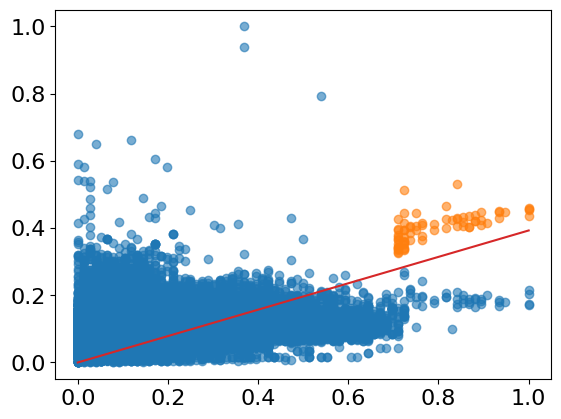

In [18]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6)
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6)
plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.show()

In [1373]:
feat_col_idx = np.where(X_exp.columns == feature_name)[0].item()

In [1374]:
# num_cols_name = ['Общая площадь объекта', 'highratio']
# cat_cols_name = ['Этажность объекта наземная', 'Квартиры среднего качества (типовые)']

In [1375]:
from functools import partial

In [1376]:
def objective(trial, i):
    cat_arr = []
    for col in cat_cols_name:
        cat_arr.append(trial.suggest_categorical(f"{col}", X_exp[col].unique()))
        
    num_arr = [] 
    for col in num_cols_name:
        num_arr.append(trial.suggest_float(f"{col}", 0, 1, step=0.01))
        # num_arr.append(trial.suggest_categorical(f"{col}", X_exp[col].unique()))
        
    prediction = xgb_exp.predict([np.hstack([[X_exp.loc[idx_sc].iloc[i, 0]], np.array(cat_arr), num_arr])])    
        
    objective = (prediction[0] - y_sc.numpy()[i][0])**2
    # objective = (prediction - y.loc[idx_sc].iloc[0])**2
    if trial.should_prune():
            raise optuna.TrialPruned()
    
    return objective


scenario_df = pd.DataFrame(columns=np.hstack([cat_cols_name, num_cols_name]))
steps = tqdm(range(len(y_sc)))
optuna.logging.set_verbosity(optuna.logging.WARNING)

for i in steps:
    objective_with_args = partial(objective, i=i)
    study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
    study.optimize(objective_with_args, n_trials=100)
    
    one_point_df = pd.DataFrame(study.best_params.items()).T.iloc[[1]].rename(columns=dict(zip(np.arange(len(cat_cols_name)+len(num_cols_name)), np.hstack([cat_cols_name, num_cols_name]))))
    
    scenario_df = pd.concat([scenario_df, one_point_df])

100%|██████████| 70/70 [06:45<00:00,  5.79s/it]


In [1377]:
# scenario_df = pd.DataFrame(study.best_params.items()).T
# scenario_df.columns = scenario_df.iloc[0]
# scenario_df = scenario_df.iloc[1:]
# scenario_df = pd.DataFrame(columns=np.hstack([num_cols_name, cat_cols_name]))
# scenario_df = pd.concat([scenario_df, pd.DataFrame(study.best_params.items()).T.iloc[[1]].rename(columns=dict(zip(np.arange(4), np.hstack([num_cols_name, cat_cols_name]))))])

In [1378]:
scenario_df = scenario_df.reset_index(drop=True)
scenario_df = pd.concat([X_exp.loc[idx_sc, feature_name].reset_index(drop=True), scenario_df], axis=1).astype(float)
prediction_exp = xgb_exp.predict(scenario_df)

In [1394]:
np.mean((prediction_exp - y_sc.numpy().flatten())**2)

0.056137282

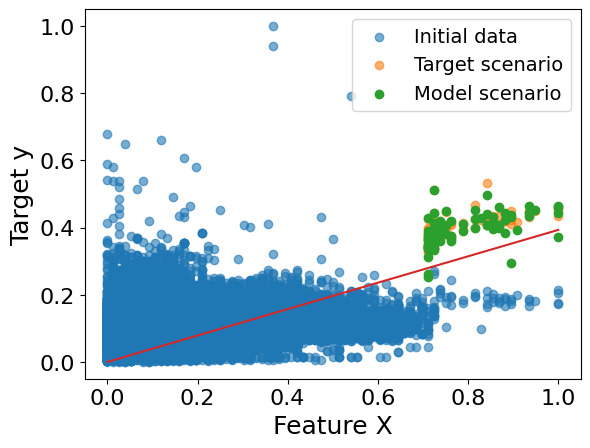

In [1379]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(X_exp.loc[idx_sc, feature_name], prediction_exp, label='Model scenario')
plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [1380]:
def objective_cat(trial, col, i):
    feat = trial.suggest_categorical(f"{col}", X_exp[col].unique())
    
    X_exp_feat = X_exp.loc[idx_sc].iloc[i].copy()
    X_exp_feat[col] = feat
    
    prediction = xgb_exp.predict([X_exp_feat.values.T])    
    objective = (prediction - y_sc.numpy()[i])**2

    if trial.should_prune():
            raise optuna.TrialPruned()
    
    return objective

def objective_num(trial, col, i):
    feat = trial.suggest_float(f"{col}", 0, 1, step=0.001)
    
    X_exp_feat = X_exp.loc[idx_sc].iloc[i].copy()
    X_exp_feat[col] = feat
    
    prediction = xgb_exp.predict([X_exp_feat.values.T])    
    objective = (prediction - y_sc.numpy()[i])**2

    if trial.should_prune():
            raise optuna.TrialPruned()
    
    return objective



all_cat_df = []
all_num_df = []
all_prediction_err_cat = []
all_prediction_err_num = []

for col in cat_cols_name:
    feat_df = []
    scenario_df = X_exp.loc[idx_sc].copy()
    steps = tqdm(range(len(y_sc)))
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    for i in steps:
        objective_with_args = partial(objective_cat, col=col, i=i)
        study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
        study.optimize(objective_with_args, n_trials=40)
        
        feat_df.append(study.best_params[col])
        
    scenario_df[col] = feat_df
    prediction_exp = xgb_exp.predict(scenario_df)
    
    all_cat_df.append(scenario_df)
    all_prediction_err_cat.append(np.mean((prediction_exp - y_sc.numpy().flatten())**2))
    
    
for col in num_cols_name:
    feat_df = []
    scenario_df = X_exp.loc[idx_sc].copy()
    steps = tqdm(range(len(y_sc)))
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    for i in steps:
        objective_with_args = partial(objective_num, col=col, i=i)
        study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
        study.optimize(objective_with_args, n_trials=40)
        
        feat_df.append(study.best_params[col])
        
    scenario_df[col] = feat_df
    prediction_exp = xgb_exp.predict(scenario_df)
    
    all_num_df.append(scenario_df)
    all_prediction_err_num.append(np.mean((prediction_exp - y_sc.numpy().flatten())**2))

  0%|          | 0/70 [00:00<?, ?it/s]

100%|██████████| 70/70 [00:06<00:00, 10.92it/s]


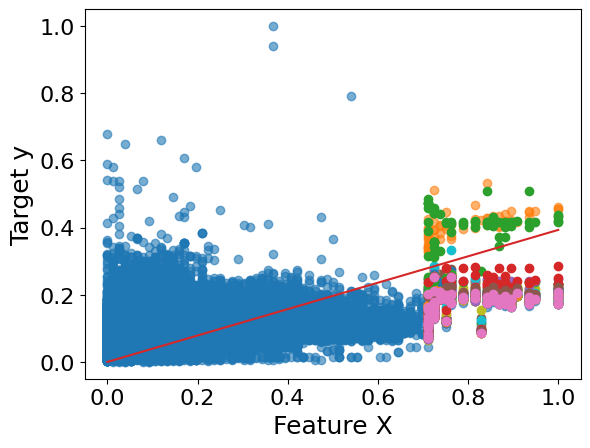

In [1387]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')

for i, d in enumerate(all_cat_df):
    plt.scatter(X_exp.loc[idx_sc, feature_name], xgb_exp.predict(d), label=f'Model scenario cat {i}')

for i, d in enumerate(all_num_df):
    plt.scatter(X_exp.loc[idx_sc, feature_name], xgb_exp.predict(d), label=f'Model scenario num {i}')

plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.xlabel('Feature X')
plt.ylabel('Target y')
# plt.legend(fontsize=10)
plt.show()

In [ ]:
best_cat = sorted(zip(cat_cols_name, all_prediction_err_cat), key=lambda x: x[1])[0][0]
best_num = sorted(zip(num_cols_name, all_prediction_err_num), key=lambda x: x[1])[0][0]

In [1414]:
from itertools import product

In [ ]:
new_feat_to_optimize = np.vstack([
        list(product([best_cat], np.delete(cat_cols_name, np.where(cat_cols_name == best_cat)[0]))),
        list(product([best_cat], num_cols_name)),
        list(product([best_num], np.delete(cat_cols_name, np.where(cat_cols_name == best_cat)[0]))),
        list(product([best_num], np.delete(num_cols_name, np.where(num_cols_name == best_num)[0])))
        ])

In [1452]:
def objective_pairs(trial, pair, i):
    col1 = pair[0]
    if col1 in cat_cols_name:
        feat1 = trial.suggest_categorical(f"{col1}", X_exp[col1].unique())
    else:
        feat1 = trial.suggest_float(f"{col1}", 0, 1, step=0.01)
        
    col2 = pair[1]
    if col2 in cat_cols_name:
        feat2 = trial.suggest_categorical(f"{col2}", X_exp[col2].unique())
    else:
        feat2 = trial.suggest_float(f"{col2}", 0, 1, step=0.01)
        
    
    X_exp_feat = X_exp.loc[idx_sc].iloc[i].copy()
    X_exp_feat[col1] = feat1
    X_exp_feat[col2] = feat2
    
    prediction = xgb_exp.predict([X_exp_feat.values.T])    
    objective = (prediction - y_sc.numpy()[i])**2
    

    if trial.should_prune():
            raise optuna.TrialPruned()
        
    
    return objective



all_pairs_df = []
all_prediction_err_pairs = []

for pair in new_feat_to_optimize:
    feat_df1 = []
    feat_df2 = []
    
    scenario_df = X_exp.loc[idx_sc].copy()
    steps = tqdm(range(len(y_sc)))
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    for i in steps:
        objective_with_args = partial(objective_pairs, pair=pair, i=i)
        study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
        study.optimize(objective_with_args, n_trials=40)
        
        feat_df1.append(study.best_params[pair[0]])
        feat_df2.append(study.best_params[pair[1]])
        
    scenario_df[pair[0]] = feat_df1
    scenario_df[pair[1]] = feat_df2
    
    prediction_exp = xgb_exp.predict(scenario_df)
    
    all_pairs_df.append(scenario_df)
    all_prediction_err_pairs.append(np.mean((prediction_exp - y_sc.numpy().flatten())**2))

100%|██████████| 70/70 [00:10<00:00,  6.61it/s]


In [1469]:
idx_best = np.array(sorted(zip(np.arange(len(all_prediction_err_pairs)), all_prediction_err_pairs), key=lambda x: x[1]))[:1, 0].astype(int)

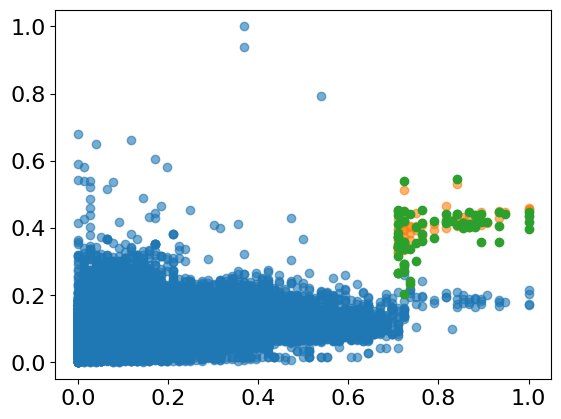

In [1470]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')

for i, d in enumerate(np.array(all_pairs_df)[idx_best]):
    plt.scatter(X_exp.loc[idx_sc, feature_name], xgb_exp.predict(d), label=f'Model scenario cat {i}')


plt.show()

In [1474]:
np.mean((xgb_exp.predict(all_pairs_df[idx_best[0]]) - y_sc.numpy().flatten())**2)

0.0025781724

In [ ]:
# for col in cat_cols_name:
#     trial.suggest_categorical(f"{col}", X_exp[col].unique())
    
#     prediction = xgb_exp.predict([np.hstack([num_arr, cat_arr, [X_exp.loc[idx_sc].iloc[i, -1]]])])    
        
#     objective = (prediction - y_sc.numpy()[i])**2
#     # objective = (prediction - y.loc[idx_sc].iloc[0])**2
#     if trial.should_prune():
#         #     raise optuna.TrialPruned()
    
#     return objective

In [77]:
col_id = np.where(X_exp.columns == cat_cols_name[0])[0][0]

In [78]:
col_id

2

In [72]:
X_exp.loc[:, X_exp.columns != cat_cols_name[0]]

,Общая площадь объекта,highratio,Квартиры среднего качества (типовые),floor
0,0.039611,0.016714,0.877598,0.065789
1,0.039611,0.016714,0.877598,0.105263
2,0.050667,0.024355,0.877598,0.000000
3,0.050667,0.024355,0.877598,0.026316
4,0.144406,0.029692,0.877598,0.144737
...,...,...,...,...
251602,0.135337,0.016308,0.122259,0.026316
251603,0.347790,0.022981,0.122259,0.092105
251604,0.347790,0.022981,0.122259,0.131579
251605,0.135337,0.016308,0.122259,0.039474


In [67]:
np.mean((prediction_exp - y_sc.numpy().flatten())**2)

0.00074681884

In [1475]:
# plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
# plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')
# plt.scatter(X_exp.loc[idx_sc, feature_name], prediction_exp, label='Model scenario')
# plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

# plt.xlabel('Feature X')
# plt.ylabel('Target y')
# plt.legend()
# plt.show()

## Genetic Algorithms

In [20]:
# def fitness(solution):
#     '''Fitness function is the Ordinary Least Squares'''
#     return 1/len(X)*np.sum(np.power(y-np.concatenate((X,np.ones((X.shape[0],1))),axis=1).dot(solution.reshape(-1,1)),2))

# def genPopulation(size=400):
#     '''Generate population of size individuals'''
#     # Coefficient and intercept in the range [-1, 1] since all data has been normalized with maximum value
#     solutions = ((np.random.rand(size, 2) * 2) - 1)
#     return solutions

# def selectBest(solutions):
#     '''Return the best 20 solution for current population'''
#     fitnesses = np.apply_along_axis(fitness, 1, solutions)
#     return solutions[np.argsort(fitnesses, axis=0)[:20],:]

# def crossover(sol1, sol2):
#     '''Perform crossover between two solutions by exchanging the intercepts and maintaining the coefficient'''
#     offsprings = np.array([[sol1[0], sol2[1]]])
#     offsprings = np.vstack((offsprings, [[sol2[0], sol1[1]]]))
#     offsprings = np.vstack((offsprings, [sol2]))
#     return offsprings

# def mutation(sol):
#     '''Perform mutation on the solution'''
#     mutationProb = 0.15
#     if np.random.rand() < mutationProb:
#         sol = sol + (((np.random.rand(2) * 2) - 1) * 0.1)
#     return sol

In [21]:
from deap import base, creator, tools, algorithms
import random

In [22]:
# def eval_func(individual):
#     prediction = xgb_exp.predict(np.hstack([[[X_exp.loc[idx_sc].iloc[0, 0]]], [individual]]))

#     return (-(prediction[0] - y_sc.numpy()[0][0])**2,)

In [24]:
def custom_mutate(individual):
    for i in range(len(individual)):
        if random.random() < 0.1:
            if i < len(cat_cols_name):  # Categorical
                individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
            else:                  # Numerical
                # idx = i - len(cat_cols_name)
                individual[i] = max(0, min(1, individual[i] + random.gauss(0, 1)))
    return individual,

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

for i, col in enumerate(cat_cols_name):
    toolbox.register(f"cat_{i}", random.sample, list(X_exp[col].unique()), 1)

for i in range(len(num_cols_name)):
    toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)

def make_individual():
    return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(len(cat_cols_name))] + \
           [toolbox.__getattribute__(f"num_{i}")() for i in range(len(num_cols_name))])


toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxBlend, alpha=0.1)
toolbox.register("mutate", custom_mutate)
toolbox.register("select", tools.selTournament, tournsize=3)


def main():
    pop = toolbox.population(n=100)
    hof = tools.HallOfFame(1, similar=np.array_equal)
    print(hof)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
    stats.register("max", lambda x: max(i[0] for i in x))

    algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
    return hof[0]


steps = tqdm(range(len(y_sc)))
best_individuals = []

for i in steps:
    def eval_func(individual):
        prediction = xgb_exp.predict(np.hstack([[[X_exp.loc[idx_sc].iloc[i, 0]]], [individual]]))

        return (-(prediction[0] - y_sc.numpy()[i][0])**2,)
    
    toolbox.register("evaluate", eval_func)
    best_individual = main()
    
    best_individuals.append(best_individual)

  1%|▏         | 1/70 [00:00<00:10,  6.32it/s]

[]
[]


  4%|▍         | 3/70 [00:00<00:09,  7.20it/s]

[]
[]


  7%|▋         | 5/70 [00:00<00:08,  7.64it/s]

...

[]
[]


 97%|█████████▋| 68/70 [00:09<00:00,  6.69it/s]

[]
[]


100%|██████████| 70/70 [00:10<00:00,  6.92it/s]

[]


In [ ]:
# scenario_df_GA = np.concatenate([X_exp.loc[idx_sc].iloc[:, 0].values.reshape(-1, 1), np.array(best_individuals)], axis=1)

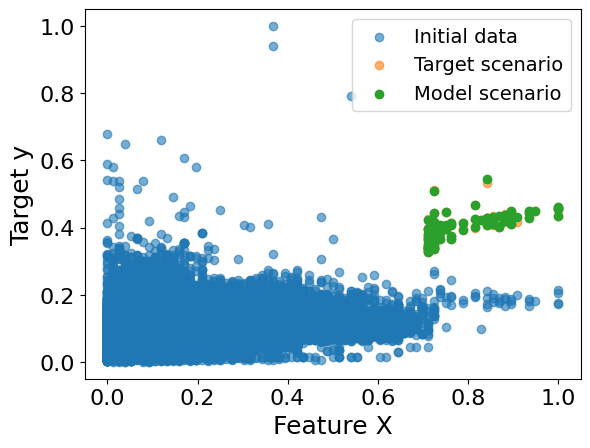

In [ ]:
scenario_df_GA = np.concatenate([X_exp.loc[idx_sc].iloc[:, 0].values.reshape(-1, 1), np.array(best_individuals)], axis=1)

plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')

plt.scatter(X_exp.loc[idx_sc].iloc[:, 0], xgb_exp.predict(scenario_df_GA), label='Model scenario')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [27]:
scenario_df_GA = pd.DataFrame(scenario_df_GA, columns=X_exp.columns)

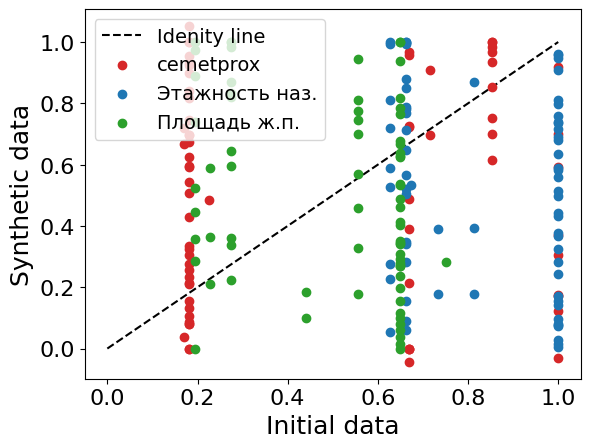

In [28]:
plt.plot([0, 1], [0, 1], '--', color='black', label='Idenity line')
plt.scatter(data.loc[idx_sc, 'cemetprox'].values, scenario_df_GA['cemetprox'].values, zorder=3, label='cemetprox', color='tab:red')
plt.scatter(data.loc[idx_sc, 'Этажность объекта наземная'].values,\
            scenario_df_GA['Этажность объекта наземная'].values, zorder=3, label='Этажность наз.', color='tab:blue')
plt.scatter(data.loc[idx_sc, 'Площадь жилых помещений объекта'].values,\
            scenario_df_GA['Площадь жилых помещений объекта'].values, zorder=3, label='Площадь ж.п.', color='tab:green')


plt.legend()
plt.xlabel('Initial data')
plt.ylabel('Synthetic data')
plt.show()

In [58]:
# import gym
# from stable_baselines3 import PPO

# # Custom environment for scenario generation
# class ScenarioEnv(gym.Env):
#     def __init__(self):
#         self.action_space = gym.spaces.Box(low=-1, high=1, shape=(4,))  # Scenario parameters
#         self.observation_space = gym.spaces.Box(low=0, high=1, shape=(10,))  # State features
#         self.state = 0.0

#     def step(self, action):
#         # Modify scenario parameters (action)
#         # Run simulation and compute reward (e.g., realism score + challenge)
#         reward = self._compute_reward(action)
#         done = True  # Scenario complete
#         return self.state, reward, done, {}

#     def reset(self):
#         # Initialize with base scenario
#         return self.state

#     def _compute_reward(self, action):
#         # print(action)
#         # Realism (adversarial score) + challenge (model failure)
#         if np.mean(action) < 0.5:
#             return 0
#         else:
#             return 1
        

# env = ScenarioEnv()
# model = PPO("MlpPolicy", env, verbose=1)
# model.learn(total_timesteps=10000)

In [113]:
from SALib.sample import saltelli
from SALib.analyze import sobol

problem = {
    'num_vars': len(X_exp.columns),
    'names': list(X_exp.columns.values),
    'bounds': list(zip(X_exp.describe().loc['min'].values, X_exp.describe().loc['max'].values))
}

N = 10_000
X_saltelli = saltelli.sample(problem, N, calc_second_order=False)
y = xgb_exp.predict(X_saltelli).flatten()

Si = sobol.analyze(problem, y, calc_second_order=False)
Si['S1'] = np.maximum(Si['S1'], 0)
Si['ST'] = np.maximum(Si['ST'], 0)

In [114]:
Si['ST'].sum() + Si['S1'].sum()

2.1089770250246325

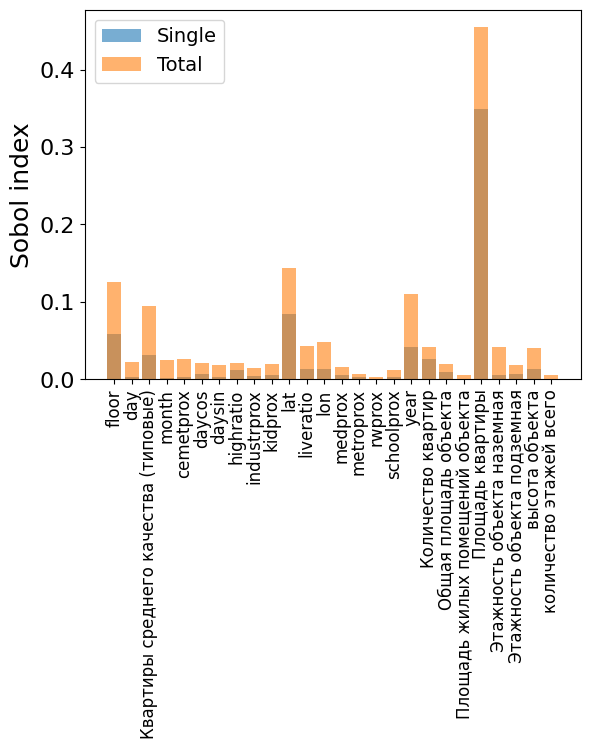

In [115]:
plt.bar(X_exp.columns, Si['S1'], alpha=0.6, label='Single')
plt.bar(X_exp.columns, Si['ST'], alpha=0.6, label='Total')

plt.ylabel('Sobol index')
plt.legend()
plt.xticks(rotation=90, fontsize=12)

plt.show()

In [126]:
linear_coefs = lr.coef_[0]

sobol_indices = Si['S1']

weights = sobol_indices + np.abs(linear_coefs)
weights /= weights.sum()

In [128]:
def custom_mutate(individual, weights, linear_coefs, target_direction, base_mutation_rate=0.1, mutation_strength=0.1):
    for i in range(len(individual)):
        mutation_prob = base_mutation_rate * weights[i]
        
        if random.random() < mutation_prob:
            if i < len(cat_cols_name): 
                individual[i] = random.sample(list(X_exp[cat_cols_name[i]].unique()), 1)[0]
            else: 
                idx = i - len(cat_cols_name)
                coef = linear_coefs[idx]
                
                direction = 1 if coef * target_direction > 0 else -1
                
                noise = direction * random.gauss(0, weights[i] * mutation_strength)
                individual[i] = max(0, min(1, individual[i] + noise))
                
    return individual,

In [ ]:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)
toolbox = base.Toolbox()

for i, col in enumerate(cat_cols_name):
    toolbox.register(f"cat_{i}", random.sample, list(X_exp[col].unique()), 1)

for i in range(len(num_cols_name)):
    toolbox.register(f"num_{i}", random.uniform, 0.0, 1.0)

def make_individual():
    return np.hstack([toolbox.__getattribute__(f"cat_{i}")() for i in range(len(cat_cols_name))] + \
           [toolbox.__getattribute__(f"num_{i}")() for i in range(len(num_cols_name))])


toolbox.register("individual", tools.initIterate, creator.Individual, make_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxBlend, alpha=0.1)
# toolbox.register("mutate", custom_mutate)

    
toolbox.register("select", tools.selTournament, tournsize=3)

In [142]:
def main(target_direction):
    toolbox.register("evaluate", eval_func, y_target=y_sc, 
                     linear_coefs=linear_coefs, weights=weights, target_direction=target_direction)
    toolbox.unregister("mutate")
    toolbox.register("mutate", custom_mutate, weights=weights, linear_coefs=linear_coefs, 
                     target_direction=target_direction)

    pop = toolbox.population(n=100)
    hof = tools.HallOfFame(1, similar=np.array_equal)
    print(hof)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", lambda x: sum(i[0] for i in x)/len(x))
    stats.register("max", lambda x: max(i[0] for i in x))

    algorithms.eaSimple(pop, toolbox, 0.1, 0.1, 10, stats=stats, halloffame=hof, verbose=False)
    return hof[0]


steps = tqdm(range(len(y_sc)))
best_individuals = []

for i in steps:
    def eval_func(individual, y_target, linear_coefs, weights, target_direction, bonus_factor=0.1):
        prediction = xgb_exp.predict(np.hstack([[[X_exp.loc[idx_sc].iloc[i, 0]]], [individual]]))
        error = -(prediction[0] - y_target.numpy()[i][0])**2

        bonus = 0
        for k, val in enumerate(individual):
            if k > len(cat_cols_name):
                idx = k - len(cat_cols_name)
                coef = linear_coefs[idx]
                base_val = X_exp.loc[idx_sc].iloc[i, k]
                
          
                if coef * target_direction > 0:  # Увеличение признака повышает таргет
                    if val > base_val:
                        bonus += weights[k] * (val - base_val) * bonus_factor
                elif coef * target_direction < 0:  # Уменьшение признака повышает таргет
                    if val < base_val:
                        bonus += weights[k] * (base_val - val) * bonus_factor
                        
        total_fitness = error + bonus
        return (total_fitness,)
    
    if y_sc.numpy().flatten()[i] > xgb_exp.predict(X_exp)[i]:
        target_direction = 1
    else:
        target_direction = -1
    
    best_individual = main(target_direction)
    
    best_individuals.append(best_individual)

  0%|          | 0/70 [00:00<?, ?it/s]

[]


  1%|▏         | 1/70 [00:01<01:19,  1.16s/it]

[]


  3%|▎         | 2/70 [00:02<01:10,  1.03s/it]

...

 97%|█████████▋| 68/70 [01:11<00:02,  1.01s/it]

[]


 99%|█████████▊| 69/70 [01:12<00:01,  1.00s/it]

[]


100%|██████████| 70/70 [01:13<00:00,  1.05s/it]


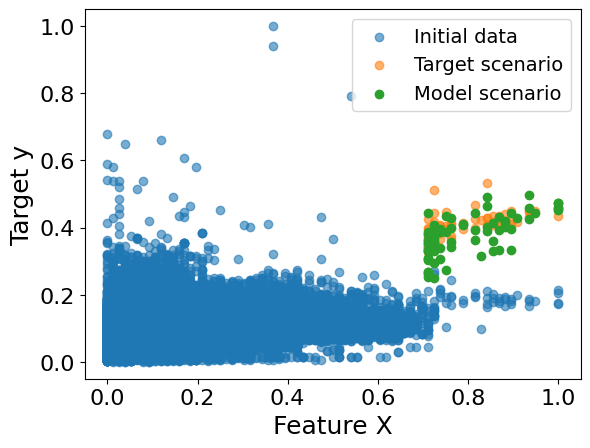

In [143]:
scenario_df_GA = np.concatenate([X_exp.loc[idx_sc].iloc[:, 0].values.reshape(-1, 1), np.array(best_individuals)], axis=1)

plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')

plt.scatter(X_exp.loc[idx_sc].iloc[:, 0], xgb_exp.predict(scenario_df_GA), label='Model scenario')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [146]:
scenario_df_GA = pd.DataFrame(scenario_df_GA, columns=X_exp.columns)

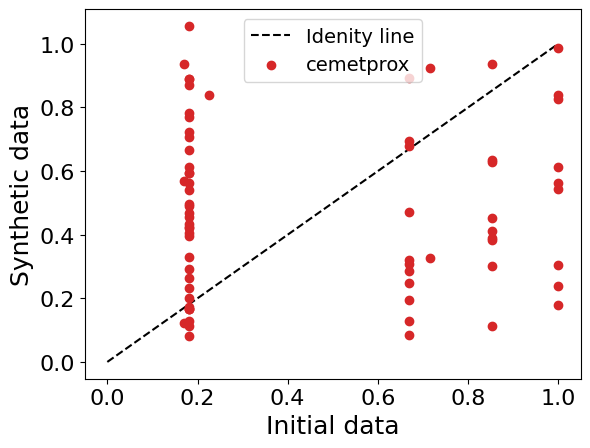

In [148]:
plt.plot([0, 1], [0, 1], '--', color='black', label='Idenity line')
plt.scatter(data.loc[idx_sc, 'cemetprox'].values, scenario_df_GA['cemetprox'].values, zorder=3, label='cemetprox', color='tab:red')
# plt.scatter(data.loc[idx_sc, 'Этажность объекта наземная'].values,\
            # scenario_df_GA['Этажность объекта наземная'].values, zorder=3, label='Этажность наз.', color='tab:blue')
# plt.scatter(data.loc[idx_sc, 'Площадь жилых помещений объекта'].values,\
            # scenario_df_GA['Площадь жилых помещений объекта'].values, zorder=3, label='Площадь ж.п.', color='tab:green')


plt.legend()
plt.xlabel('Initial data')
plt.ylabel('Synthetic data')
plt.show()